# 🔁 Modèle LSTM — Détection de Commentaires Toxiques
**Dataset :** Jigsaw Toxic Comment Classification  
**Architecture :** LSTM (Long Short-Term Memory)  

## 1. 📦 Installation & Imports

In [ ]:
# Installations supplémentaires si nécessaire
# !pip install -q scikit-learn matplotlib seaborn

import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout,
    SpatialDropout1D, GlobalMaxPooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU disponible     : {tf.config.list_physical_devices("GPU")}')

TensorFlow version : 2.19.0
GPU disponible     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. 🔗 Connexion Google Drive & Chargement des données

In [ ]:

# ─── CHEMIN de ma structure Drive ───────────────────────────────
gdown.download('https://drive.google.com/uc?id=1Z2zgdnGuD61vJ0QtfPGlvmjvM6x1LHUq', 'train.csv', quiet=False)
gdown.download('https://drive.google.com/uc?id=1uDzllIpQ-08vlNlG21k5xVk2WdrOeTVz', 'test.csv', quiet=False)
# ──────────────────────────────────────────────────────────────────────────────
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print(f'Train shape : {train_df.shape}')
print(f'Test  shape : {test_df.shape}')
train_df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train shape : (159571, 8)
Test  shape : (153164, 2)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0


## 3. 🧹 Preprocessing du texte

Nettoyage du texte...
Tokenisation...

Vocabulaire     : 173,161 mots
X_train shape   : (143613, 200)
X_val   shape   : (15958, 200)


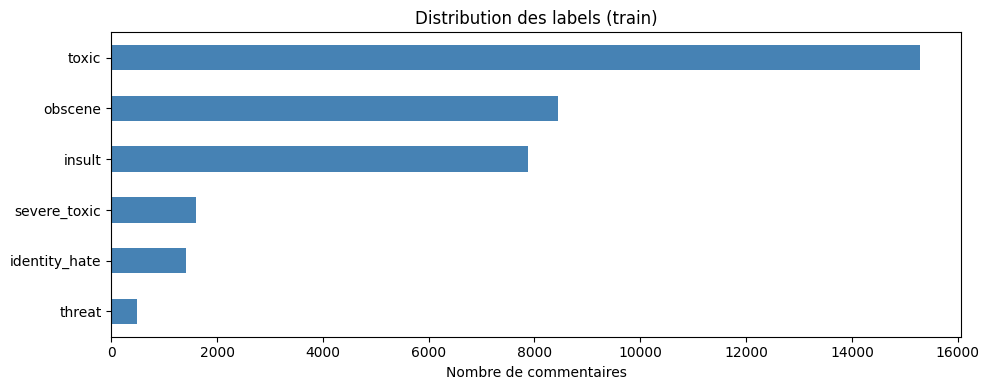

In [ ]:
import re

LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# ─── Hyperparamètres ──────────────────────────────────────────────────────────
MAX_FEATURES  = 30000   # taille du vocabulaire
MAX_LEN       = 200     # longueur max des séquences
EMBED_DIM     = 128     # dimension des embeddings
LSTM_UNITS    = 64
DROPOUT_RATE  = 0.3
BATCH_SIZE    = 256
EPOCHS        = 10
VAL_SPLIT     = 0.1
# ──────────────────────────────────────────────────────────────────────────────

def clean_text(text):
    """Nettoyage basique du texte."""
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' url ', text)
    text = re.sub(r'[^a-z0-9\s!?.,]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print('Nettoyage du texte...')
train_df['clean_text'] = train_df['comment_text'].apply(clean_text)
test_df['clean_text']  = test_df['comment_text'].apply(clean_text)

# Tokenisation
print('Tokenisation...')
tokenizer = Tokenizer(num_words=MAX_FEATURES, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['clean_text'])

X_train_seq = tokenizer.texts_to_sequences(train_df['clean_text'])
X_test_seq  = tokenizer.texts_to_sequences(test_df['clean_text'])

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

y = train_df[LABELS].values

# Split train / validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_pad, y, test_size=VAL_SPLIT, random_state=42, stratify=y[:, 0]
)

print(f'\nVocabulaire     : {len(tokenizer.word_index):,} mots')
print(f'X_train shape   : {X_tr.shape}')
print(f'X_val   shape   : {X_val.shape}')

# Distribution des labels
fig, ax = plt.subplots(figsize=(10, 4))
train_df[LABELS].sum().sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Distribution des labels (train)')
ax.set_xlabel('Nombre de commentaires')
plt.tight_layout()
plt.show()

## 4. 🏗️ Architecture LSTM

In [ ]:
def build_lstm_model(vocab_size, embed_dim, max_len, lstm_units, dropout_rate, n_labels=6):
    """Construit le modèle LSTM pour classification multi-label."""
    model = Sequential([
        # Embedding
        Embedding(input_dim=vocab_size, output_dim=embed_dim,
                  input_length=max_len, name='embedding'),
        SpatialDropout1D(dropout_rate),

        # LSTM
        LSTM(lstm_units, return_sequences=True, name='lstm_1'),
        Dropout(dropout_rate),
        LSTM(lstm_units // 2, return_sequences=False, name='lstm_2'),
        Dropout(dropout_rate),

        # Classifieur
        Dense(64, activation='relu', name='dense_1'),
        Dropout(0.2),
        Dense(n_labels, activation='sigmoid', name='output'),
    ], name='LSTM_ToxicDetector')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
    )
    return model

model_lstm = build_lstm_model(
    vocab_size=MAX_FEATURES + 1,
    embed_dim=EMBED_DIM,
    max_len=MAX_LEN,
    lstm_units=LSTM_UNITS,
    dropout_rate=DROPOUT_RATE
)
model_lstm.summary()

Model: "LSTM_ToxicDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. 🏋️ Entraînement

In [ ]:
# Poids de classe pour compenser le déséquilibre
pos_weight = (y_tr == 0).sum(axis=0) / (y_tr == 1).sum(axis=0)
class_weight_dict = {i: float(pos_weight[i]) for i in range(len(LABELS))}
print('Poids de classe :', {LABELS[i]: round(class_weight_dict[i], 1) for i in range(6)})

callbacks = [
    EarlyStopping(monitor='val_auc', patience=3, mode='max',
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=2,
                     mode='max', min_lr=1e-5, verbose=1),
    ModelCheckpoint(
        filepath=os.path.join(RESULTS_DIR, 'best_lstm.keras'),
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

t0 = time.time()
history_lstm = model_lstm.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)
train_time_lstm = time.time() - t0
print(f'\nTemps entraînement : {train_time_lstm/60:.1f} min')

Poids de classe : {'toxic': 9.4, 'severe_toxic': 98.3, 'obscene': 17.9, 'threat': 334.5, 'insult': 19.3, 'identity_hate': 113.7}
Epoch 1/10
560/561 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5318 - auc: 0.4933 - loss: 0.2167
Epoch 1: val_auc improved from None to 0.51500, saving model to /content/drive/MyDrive/toxic_comment_project/results/best_lstm.keras

Epoch 1: finished saving model to /content/drive/MyDrive/toxic_comment_project/results/best_lstm.keras
561/561 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.7150 - auc: 0.4949 - loss: 0.1649 - val_accuracy: 0.9953 - val_auc: 0.5150 - val_loss: 0.1418 - learning_rate: 0.0010
Epoch 2/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9348 - auc: 0.5449 - loss: 0.1415
Epoch 2: val_auc improved from 0.51500 to 0.94663, saving model to /content/drive/MyDrive/toxic_comment_project/results/best_lstm.keras

Epoch 2: finished saving model to /content/drive/MyDrive/toxic_comment_project/results/best_lstm.keras
561/561 ━━━━━━━━━

## 6. 📈 Courbes d'apprentissage

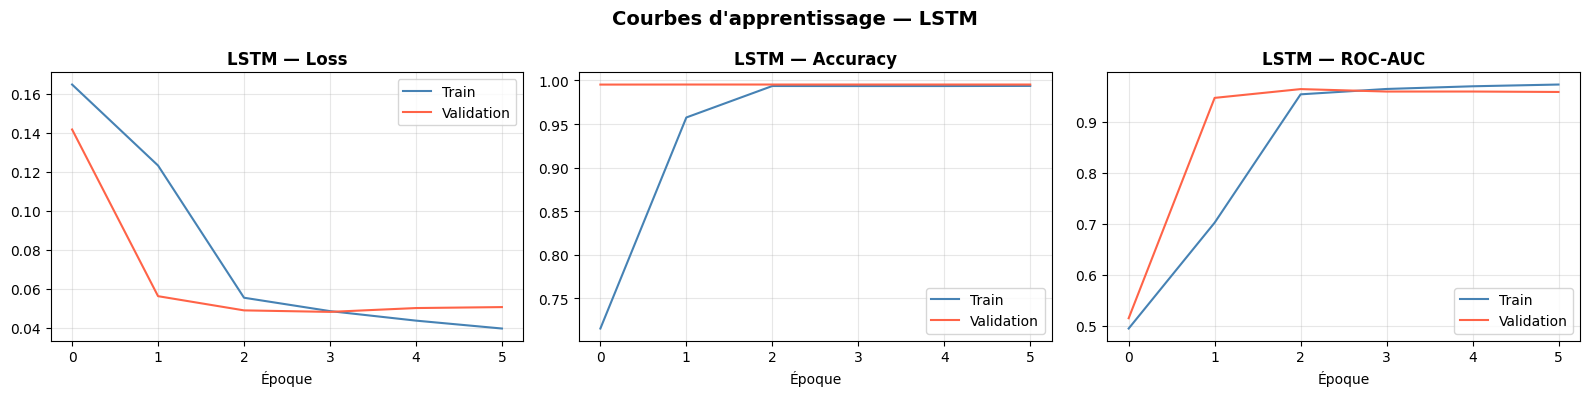

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
hist = history_lstm.history
metrics_plot = [('loss', 'Loss'), ('accuracy', 'Accuracy'), ('auc', 'ROC-AUC')]

for ax, (m, title) in zip(axes, metrics_plot):
    ax.plot(hist[m], label='Train', color='steelblue')
    ax.plot(hist[f'val_{m}'], label='Validation', color='tomato')
    ax.set_title(f'LSTM — {title}', fontweight='bold')
    ax.set_xlabel('Époque')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Courbes d\'apprentissage — LSTM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'lstm_history.png'), dpi=150)
plt.show()

## 7. 📊 Évaluation complète

In [ ]:
def evaluate_model(model, X_val, y_val, model_name='Modèle', threshold=0.5):
    """Évaluation complète : ROC-AUC, F1, matrice de confusion."""
    y_proba = model.predict(X_val, batch_size=512, verbose=0)
    y_pred  = (y_proba >= threshold).astype(int)

    # ROC-AUC
    roc_macro = roc_auc_score(y_val, y_proba, average='macro')

    # F1
    f1_macro  = f1_score(y_val, y_pred, average='macro',    zero_division=0)
    f1_micro  = f1_score(y_val, y_pred, average='micro',    zero_division=0)
    f1_weight = f1_score(y_val, y_pred, average='weighted', zero_division=0)

    print(f'\n{"═"*50}')
    print(f'  {model_name} — Résultats')
    print(f'{"═"*50}')
    print(f'  ROC-AUC macro : {roc_macro:.4f}')
    print(f'  F1 macro      : {f1_macro:.4f}')
    print(f'  F1 micro      : {f1_micro:.4f}')
    print(f'  F1 weighted   : {f1_weight:.4f}')
    print()

    # AUC par label
    print('  AUC par label :')
    auc_per_label = {}
    for i, label in enumerate(LABELS):
        auc_l = roc_auc_score(y_val[:, i], y_proba[:, i])
        auc_per_label[label] = auc_l
        print(f'    {label:20s} → {auc_l:.4f}')

    return {
        'roc_auc_macro': roc_macro,
        'f1_macro': f1_macro,
        'f1_micro': f1_micro,
        'f1_weighted': f1_weight,
        'auc_per_label': auc_per_label,
        'y_proba': y_proba,
        'y_pred': y_pred
    }

results_lstm = evaluate_model(model_lstm, X_val, y_val, 'LSTM')


══════════════════════════════════════════════════
  LSTM — Résultats
══════════════════════════════════════════════════
  ROC-AUC macro : 0.9741
  F1 macro      : 0.3799
  F1 micro      : 0.7245
  F1 weighted   : 0.6913

  AUC par label :
    toxic                → 0.9776
    severe_toxic         → 0.9876
    obscene              → 0.9894
    threat               → 0.9438
    insult               → 0.9849
    identity_hate        → 0.9615


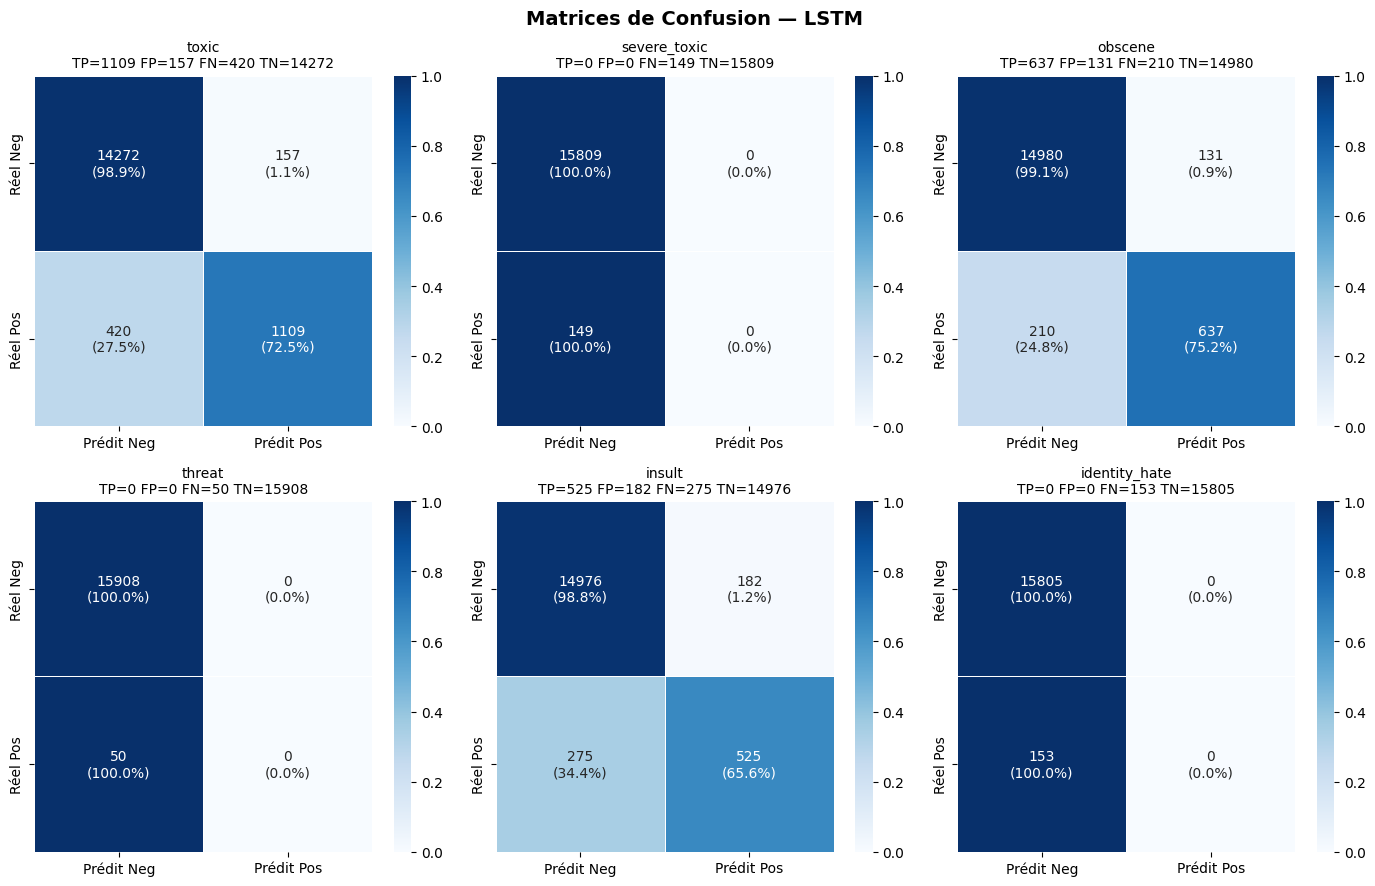

In [ ]:
# Matrices de confusion (6 labels)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for idx, label in enumerate(LABELS):
    cm = confusion_matrix(y_val[:, idx], results_lstm['y_pred'][:, idx])
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    annot = np.array([[f'{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)'
                       for j in range(2)] for i in range(2)])

    sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues',
                ax=axes[idx], vmin=0, vmax=1, linewidths=0.5,
                xticklabels=['Prédit Neg', 'Prédit Pos'],
                yticklabels=['Réel Neg', 'Réel Pos'])

    tn, fp, fn, tp = cm.ravel()
    axes[idx].set_title(f'{label}\nTP={tp} FP={fp} FN={fn} TN={tn}', fontsize=10)

plt.suptitle('Matrices de Confusion — LSTM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'lstm_confusion.png'), dpi=150)
plt.show()

## 8. 💾 Sauvegarde des résultats

In [ ]:
# Prédictions sur le test set
test_preds = model_lstm.predict(X_test_pad, batch_size=512, verbose=1)

sub_df = pd.DataFrame(test_preds, columns=LABELS)
sub_df.insert(0, 'id', test_df['id'])
sub_df.to_csv(os.path.join(RESULTS_DIR, 'submission_lstm.csv'), index=False)

# Sauvegarde des métriques pour la comparaison finale
metrics_summary = {
    'model': 'LSTM',
    'roc_auc_macro': results_lstm['roc_auc_macro'],
    'f1_macro':      results_lstm['f1_macro'],
    'f1_micro':      results_lstm['f1_micro'],
    'f1_weighted':   results_lstm['f1_weighted'],
    'train_time_min': round(train_time_lstm / 60, 2),
    'n_params':       model_lstm.count_params()
}
pd.DataFrame([metrics_summary]).to_csv(os.path.join(RESULTS_DIR, 'metrics_lstm.csv'), index=False)

print('✅ Fichiers sauvegardés dans Drive :')
print('   best_lstm.keras')
print('   lstm_history.png')
print('   lstm_confusion.png')
print('   submission_lstm.csv')
print('   metrics_lstm.csv')
print(f'\n📊 ROC-AUC final : {results_lstm["roc_auc_macro"]:.4f}')

300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
✅ Fichiers sauvegardés dans Drive :
   best_lstm.keras
   lstm_history.png
   lstm_confusion.png
   submission_lstm.csv
   metrics_lstm.csv

📊 ROC-AUC final : 0.9741
